# Fund Performance Analytics

## 1. Import Required Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

## 2. Load Datasets

In [ ]:
# Load cleaned d..

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
performance_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")


## 3. Compute Daily Returns

In [24]:
# Convert date column to datetime and sort data

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    by=["amfi_code", "date"]
).reset_index(drop=True)

In [25]:
# Compute Daily Return = (NAV_t / NAV_t-1) - 1

nav_df["previous_nav"] = (
    nav_df.groupby("amfi_code")["nav"].shift(1)
)

nav_df["daily_return"] = (
    nav_df["nav"] / nav_df["previous_nav"]
) - 1

nav_df.head(10)

,amfi_code,date,nav,daily_return,previous_nav
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,520.4608
2,100016,2022-01-05,521.7239,0.012865,515.0971
3,100016,2022-01-06,515.7880,-0.011377,521.7239
4,100016,2022-01-07,515.1639,-0.001210,515.7880
5,100016,2022-01-10,510.7136,-0.008639,515.1639
6,100016,2022-01-11,513.5542,0.005562,510.7136
7,100016,2022-01-12,512.3195,-0.002404,513.5542
8,100016,2022-01-13,510.2445,-0.004050,512.3195
9,100016,2022-01-14,514.3636,0.008073,510.2445


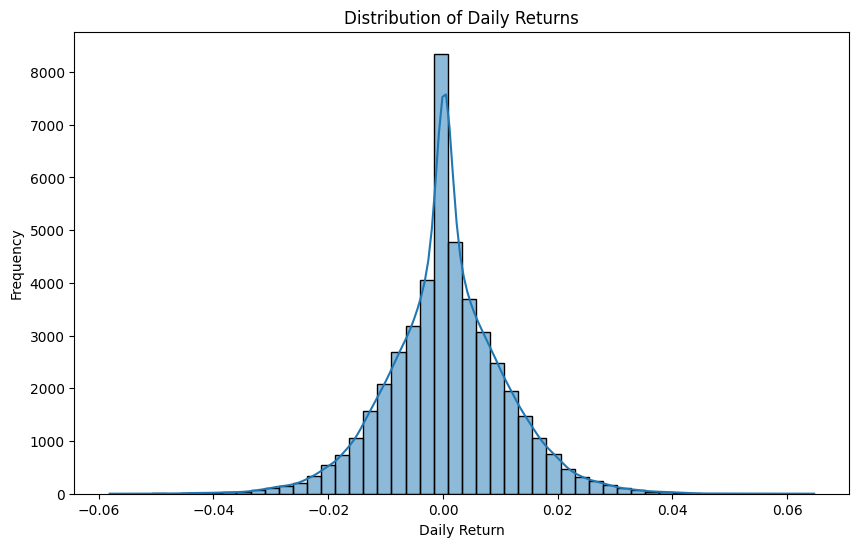

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [26]:
# Validate Daily Return Distribution

plt.figure(figsize=(10, 6))

sns.histplot(nav_df["daily_return"].dropna(), bins=50, kde=True)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

# Summary Statistics
display(nav_df["daily_return"].describe())

## 4. Compute CAGR (1Y, 3Y, Full Period)   

> **Note:** The assignment requests 1-Year, 3-Year, and 5-Year CAGR. However, the available NAV history spans from **03-Jan-2022** to **29-May-2026** (approximately **4.4 years**). Therefore, 1-Year and 3-Year CAGR are calculated as requested, while the third metric is reported as **Full Period CAGR (4.4 Years)** instead of a 5-Year CAGR to accurately reflect the available data.

In [30]:
# first and last NAV for each fund

cagr_df = (
    nav_df.groupby("amfi_code")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )
    .reset_index()
)

# Calculate investment period in years
cagr_df["years"] = (
    (cagr_df["end_date"] - cagr_df["start_date"]).dt.days
) / 365.25

cagr_df.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726


In [33]:
# Function to calculate CAGR for a given investment period

def calculate_cagr(nav_data, years):

    latest_date = nav_data["date"].max()

    # Convert years into approximate days
    target_date = latest_date - pd.Timedelta(days=years * 365.25)

    cagr_list = []

    for amfi_code, group in nav_data.groupby("amfi_code"):

        group = group.sort_values("date")

        # Latest NAV
        end_row = group.iloc[-1]

        # Closest available NAV to target date
        start_row = group.iloc[
            (group["date"] - target_date).abs().argsort()[:1]
        ]

        start_nav = start_row["nav"].values[0]
        end_nav = end_row["nav"]

        cagr = (end_nav / start_nav) ** (1 / years) - 1

        cagr_list.append({
            "amfi_code": amfi_code,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(cagr_list)

In [34]:
# Calculate CAGR

cagr_1yr = calculate_cagr(nav_df, 1)

cagr_3yr = calculate_cagr(nav_df, 3)

# Full period CAGR (approximately 4.4 years)

full_period = round(
    (nav_df["date"].max() - nav_df["date"].min()).days / 365.25,
    2
)

cagr_full = calculate_cagr(nav_df, full_period)

# Merge all results

cagr_table = (
    cagr_1yr
    .merge(cagr_3yr, on="amfi_code")
    .merge(cagr_full, on="amfi_code")
)

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_4.4Y
0,100016,-0.022243,0.012926,0.026369
1,100025,0.037050,0.039164,0.044579
2,100033,0.532324,0.324425,0.301210
3,101206,0.479241,0.289677,0.235367
4,101207,-0.239860,-0.041524,0.079383


In [44]:
# Add scheme names to the CAGR comparison table

cagr_table = cagr_table.merge(
    performance_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Reorder columns
cagr_table = cagr_table[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        f"CAGR_{full_period}Y"
    ]
]

cagr_table.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_4.4Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.026369
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.044579
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.301210
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.235367
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.079383


In [ ]:
#  as percentages

cagr_display = cagr_table.copy()

for col in cagr_display.columns[2:]:
    cagr_display[col] = (cagr_display[col] * 100).round(2)

cagr_display.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_4.4Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.64
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,4.46
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,30.12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,23.54
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,7.94


## 5. Compute Sharpe Ratio

In [54]:
# Risk-free rate (annual)
risk_free_rate = 0.065

# Convert annual risk-free rate to daily
daily_rf = risk_free_rate / 252

sharpe_list = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    mean_return = returns.mean()
    std_return = returns.std()

    sharpe = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)

    sharpe_list.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df.head(40)

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661
5,101208,-0.815567
6,102885,0.817099
7,102886,-0.205832
8,102887,0.619518
9,118632,1.081659


In [52]:
# Rank funds based on Sharpe Ratio

sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False, method="dense")
)

sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Rank"
)

sharpe_df.head(40)

,amfi_code,scheme_name_x,Sharpe_Ratio,Sharpe_Rank,scheme_name_y
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,1.0,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,Kotak Flexicap Fund - Regular - Growth,1.306744,2.0,Kotak Flexicap Fund - Regular - Growth
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,3.0,Mirae Asset Tax Saver Fund - Regular - Growth
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267,4.0,SBI Bluechip Fund - Regular Plan - Growth
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101,5.0,ICICI Pru Midcap Fund - Regular - Growth
5,149323,DSP Midcap Fund - Regular - Growth,1.132122,6.0,DSP Midcap Fund - Regular - Growth
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,7.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
7,118632,Nippon India Large Cap Fund - Regular - Growth,1.081659,8.0,Nippon India Large Cap Fund - Regular - Growth
8,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213,9.0,ABSL Frontline Equity Fund - Regular - Growth
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,10.0,ICICI Pru Bluechip Fund - Direct - Growth


In [53]:
# Add scheme names

sharpe_df = sharpe_df.merge(
    performance_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sharpe_df = sharpe_df[
    [
        "amfi_code",
        "scheme_name",
        "Sharpe_Ratio",
        "Sharpe_Rank"
    ]
]

sharpe_df.head(40)

,amfi_code,scheme_name,Sharpe_Ratio,Sharpe_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,1.0
1,120843,Kotak Flexicap Fund - Regular - Growth,1.306744,2.0
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,3.0
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267,4.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101,5.0
5,149323,DSP Midcap Fund - Regular - Growth,1.132122,6.0
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,7.0
7,118632,Nippon India Large Cap Fund - Regular - Growth,1.081659,8.0
8,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213,9.0
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,10.0


## 6. Compute Sortino Ratio

In [55]:
# Compute Sortino Ratio for all funds

risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sortino_list = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # Downside returns (negative returns only)
    downside_returns = returns[returns < 0]

    mean_return = returns.mean()
    downside_std = downside_returns.std()

    sortino = (
        (mean_return - daily_rf)
        / downside_std
    ) * np.sqrt(252)

    sortino_list.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_list)

# Display all funds
display(sortino_df)

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644
5,101208,-1.681038
6,102885,1.435742
7,102886,-0.347222
8,102887,1.088755
9,118632,1.850133


In [56]:
# Rank funds based on Sortino Ratio

sortino_df["Sortino_Rank"] = (
    sortino_df["Sortino_Ratio"]
    .rank(ascending=False, method="dense")
)

sortino_df = sortino_df.sort_values(
    by="Sortino_Rank"
)

# Display all ranked funds
display(sortino_df)

,amfi_code,Sortino_Ratio,Sortino_Rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [57]:
# Add scheme names

sortino_df = sortino_df.merge(
    performance_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df[
    [
        "amfi_code",
        "scheme_name",
        "Sortino_Ratio",
        "Sortino_Rank"
    ]
]

# Display complete comparison table (all 40 funds)
display(sortino_df)

,amfi_code,scheme_name,Sortino_Ratio,Sortino_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.385644,1.0
1,120843,Kotak Flexicap Fund - Regular - Growth,2.364320,2.0
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914,3.0
3,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140267,4.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029353,5.0
5,149323,DSP Midcap Fund - Regular - Growth,1.875101,6.0
6,118632,Nippon India Large Cap Fund - Regular - Growth,1.850133,7.0
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134,8.0
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.805294,9.0
9,101206,ABSL Frontline Equity Fund - Regular - Growth,1.799563,10.0


## 7. Compute Alpha & Beta

In [61]:
# Prepare NIFTY100 benchmark returns

benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

nifty100_df = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

# Calculate daily benchmark returns
nifty100_df["benchmark_return"] = (
    nifty100_df["close_value"] /
    nifty100_df["close_value"].shift(1)
) - 1

display(nifty100_df)

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
...,...,...,...,...
2295,2026-05-25,NIFTY100,19245.64,0.002732
2296,2026-05-26,NIFTY100,19228.08,-0.000912
2297,2026-05-27,NIFTY100,19489.24,0.013582
2298,2026-05-28,NIFTY100,19677.97,0.009684


In [63]:
# Merge fund returns with benchmark returns

merged_returns = nav_df.merge(
    nifty100_df[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

display(merged_returns)

,amfi_code,date,nav,daily_return,previous_nav,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN,NaN
1,100025,2022-01-03,26.3169,NaN,NaN,NaN
2,100033,2022-01-03,107.3758,NaN,NaN,NaN
3,101206,2022-01-03,305.0996,NaN,NaN,NaN
4,101207,2022-01-03,38.5736,NaN,NaN,NaN
...,...,...,...,...,...,...
45995,148568,2026-05-29,205.4510,0.011354,203.1444,0.000931
45996,148569,2026-05-29,97.7435,0.016042,96.2003,0.000931
45997,149322,2026-05-29,606.2349,0.002064,604.9862,0.000931
45998,149323,2026-05-29,245.3651,-0.002778,246.0486,0.000931


In [69]:
# Compute Alpha and Beta using linear regression

alpha_beta_list = []

for amfi_code, group in merged_returns.groupby("amfi_code"):

    group = group.dropna(subset=["daily_return", "benchmark_return"])

    slope, intercept, r_value, p_value, std_err = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    alpha_beta_list.append({
        "amfi_code": amfi_code,
        "Alpha": intercept * 252,
        "Beta": slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

display(alpha_beta_df)

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289
5,101208,0.060861,0.000267
6,102885,0.170488,-0.019487
7,102886,0.028969,-0.042125
8,102887,0.162113,0.016683
9,118632,0.218294,-0.008354


In [70]:
# Add scheme names

alpha_beta_df = alpha_beta_df.merge(
    performance_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Reorder columns
alpha_beta_df = alpha_beta_df[
    [
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta"
    ]
]

# Display all 40 funds
display(alpha_beta_df)

,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289
5,101208,ABSL Liquid Fund - Regular - Growth,0.060861,0.000267
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.170488,-0.019487
7,102886,UTI Mid Cap Fund - Regular - Growth,0.028969,-0.042125
8,102887,UTI Flexi Cap Fund - Regular - Growth,0.162113,0.016683
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.218294,-0.008354


## 8. Compute Maximum Drawdown

In [71]:
# Calculate running maximum NAV and drawdown

drawdown_df = nav_df.copy()

drawdown_df["running_max"] = (
    drawdown_df.groupby("amfi_code")["nav"]
    .cummax()
)

drawdown_df["drawdown"] = (
    drawdown_df["nav"] /
    drawdown_df["running_max"]
) - 1

display(drawdown_df)

,amfi_code,date,nav,daily_return,previous_nav,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,515.0971,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,515.7880,521.7239,-0.012574
...,...,...,...,...,...,...,...
45995,149324,2026-05-25,292.4810,0.012106,288.9825,336.6937,-0.131314
45996,149324,2026-05-26,291.2707,-0.004138,292.4810,336.6937,-0.134909
45997,149324,2026-05-27,288.8007,-0.008480,291.2707,336.6937,-0.142245
45998,149324,2026-05-28,280.6873,-0.028093,288.8007,336.6937,-0.166342


In [72]:
# Maximum Drawdown for each fund

max_drawdown_df = (
    drawdown_df.groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
)

max_drawdown_df.rename(
    columns={"drawdown": "Maximum_Drawdown"},
    inplace=True
)

display(max_drawdown_df)

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469
5,101208,-0.001622
6,102885,-0.108599
7,102886,-0.280011
8,102887,-0.215398
9,118632,-0.174141


In [74]:
# Find peak date and trough date for maximum drawdown

drawdown_periods = []

for amfi_code, group in drawdown_df.groupby("amfi_code"):

    group = group.sort_values("date").reset_index(drop=True)

    # Trough (maximum drawdown)
    trough_idx = group["drawdown"].idxmin()

    trough_date = group.loc[trough_idx, "date"]
    max_drawdown = group.loc[trough_idx, "drawdown"]

    # Peak before trough
    peak_idx = group.loc[:trough_idx, "nav"].idxmax()
    peak_date = group.loc[peak_idx, "date"]

    drawdown_periods.append({
        "amfi_code": amfi_code,
        "Maximum_Drawdown": max_drawdown,
        "Peak_Date": peak_date,
        "Trough_Date": trough_date
    })

drawdown_period_df = pd.DataFrame(drawdown_periods)

display(drawdown_period_df)

,amfi_code,Maximum_Drawdown,Peak_Date,Trough_Date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11
5,101208,-0.001622,2023-09-05,2023-09-12
6,102885,-0.108599,2022-02-03,2022-03-29
7,102886,-0.280011,2025-01-07,2026-04-27
8,102887,-0.215398,2022-01-03,2022-07-04
9,118632,-0.174141,2024-01-02,2024-07-19


In [75]:
# Add scheme names

drawdown_period_df = drawdown_period_df.merge(
    performance_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

drawdown_period_df = drawdown_period_df[
    [
        "amfi_code",
        "scheme_name",
        "Maximum_Drawdown",
        "Peak_Date",
        "Trough_Date"
    ]
]

# Display all 40 funds
display(drawdown_period_df)

,amfi_code,scheme_name,Maximum_Drawdown,Peak_Date,Trough_Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-03-30,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-05-23,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,2022-03-11,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-04-24,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2024-11-21,2026-05-11
5,101208,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-05,2023-09-12
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599,2022-02-03,2022-03-29
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.280011,2025-01-07,2026-04-27
8,102887,UTI Flexi Cap Fund - Regular - Growth,-0.215398,2022-01-03,2022-07-04
9,118632,Nippon India Large Cap Fund - Regular - Growth,-0.174141,2024-01-02,2024-07-19


## 9. Generate Fund Scorecard

In [76]:
# Merge all required metrics

scorecard_df = performance_df[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard_df = scorecard_df.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard_df = scorecard_df.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

scorecard_df = scorecard_df.merge(
    drawdown_period_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code",
    how="left"
)

display(scorecard_df)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,14.84,1.55,-0.201517,0.037476,-0.247344
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,13.38,0.92,0.775790,0.177298,-0.152000
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,15.29,0.78,0.300612,0.119891,-0.211173
9,100025,HDFC Short Term Debt Fund - Regular - Growth,7.37,0.56,-0.567095,0.042818,-0.043083


In [77]:
# Create ranking columns

scorecard_df["Return_Rank"] = scorecard_df["return_3yr_pct"].rank(
    ascending=False,
    method="dense"
)

scorecard_df["Sharpe_Rank"] = scorecard_df["Sharpe_Ratio"].rank(
    ascending=False,
    method="dense"
)

scorecard_df["Alpha_Rank"] = scorecard_df["Alpha"].rank(
    ascending=False,
    method="dense"
)

# Lower expense ratio is better
scorecard_df["Expense_Rank"] = scorecard_df["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

# Smaller drawdown (less negative) is better
scorecard_df["Drawdown_Rank"] = scorecard_df["Maximum_Drawdown"].rank(
    ascending=False,
    method="dense"
)

display(scorecard_df)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124,26.0,4.0,10.0,24.0,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035,34.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,18.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742,2.0,32.0,36.0,5.0,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,8.0,5.0
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,14.84,1.55,-0.201517,0.037476,-0.247344,16.0,35.0,39.0,25.0,34.0
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,13.38,0.92,0.775790,0.177298,-0.152000,24.0,18.0,16.0,13.0,18.0
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,15.0,20.0
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,15.29,0.78,0.300612,0.119891,-0.211173,14.0,27.0,26.0,9.0,29.0
9,100025,HDFC Short Term Debt Fund - Regular - Growth,7.37,0.56,-0.567095,0.042818,-0.043083,36.0,39.0,38.0,2.0,4.0


In [ ]:
#  ranks into scores and calculate weighted fund score

max_rank = scorecard_df["Return_Rank"].max()

scorecard_df["Fund_Score"] = (
    (max_rank - scorecard_df["Return_Rank"] + 1) * 0.30 +
    (max_rank - scorecard_df["Sharpe_Rank"] + 1) * 0.25 +
    (max_rank - scorecard_df["Alpha_Rank"] + 1) * 0.20 +
    (max_rank - scorecard_df["Expense_Rank"] + 1) * 0.15 +
    (max_rank - scorecard_df["Drawdown_Rank"] + 1) * 0.10
)

display(scorecard_df)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124,26.0,4.0,10.0,24.0,17.0,24.90
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035,34.0,12.0,15.0,4.0,11.0,23.10
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,18.0,36.0,30.70
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742,2.0,32.0,36.0,5.0,40.0,20.45
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,8.0,5.0,11.85
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,14.84,1.55,-0.201517,0.037476,-0.247344,16.0,35.0,39.0,25.0,34.0,12.50
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,13.38,0.92,0.775790,0.177298,-0.152000,24.0,18.0,16.0,13.0,18.0,22.35
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,15.0,20.0,30.80
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,15.29,0.78,0.300612,0.119891,-0.211173,14.0,27.0,26.0,9.0,29.0,20.60
9,100025,HDFC Short Term Debt Fund - Regular - Growth,7.37,0.56,-0.567095,0.042818,-0.043083,36.0,39.0,38.0,2.0,4.0,12.15


In [79]:
# Final scorecard

scorecard_df = scorecard_df.sort_values(
    by="Fund_Score",
    ascending=False
)

display(scorecard_df)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,14.0,25.0,32.15
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,19.0,13.0,32.05
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,15.0,20.0,30.80
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,18.0,36.0,30.70
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,20.0,8.0,30.45
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,22.0,37.0,28.55
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,30.0,22.0,28.50
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,11.0,12.0,27.05
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,15.0,28.0,26.90
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,29.0,21.0,26.10


In [80]:
# Normalize Fund Score to a 0–100 scale

scorecard_df["Fund_Score"] = (
    (scorecard_df["Fund_Score"] - scorecard_df["Fund_Score"].min())
    /
    (scorecard_df["Fund_Score"].max() - scorecard_df["Fund_Score"].min())
) * 100

scorecard_df["Fund_Score"] = scorecard_df["Fund_Score"].round(2)

display(scorecard_df)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,14.0,25.0,100.00
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,19.0,13.0,99.54
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,15.0,20.0,93.74
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,18.0,36.0,93.27
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,20.0,8.0,92.11
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,22.0,37.0,83.29
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,30.0,22.0,83.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,11.0,12.0,76.33
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,15.0,28.0,75.64
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,29.0,21.0,71.93


## 10. Benchmark Comparison

In [81]:
# Select Top 5 funds

top5_funds = scorecard_df.head(5)

display(top5_funds)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,14.0,25.0,100.00
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,19.0,13.0,99.54
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,15.0,20.0,93.74
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,18.0,36.0,93.27
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,20.0,8.0,92.11


In [82]:
# Filter NAV data for the last 3 years

latest_date = nav_df["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav_3yr = nav_df[
    nav_df["date"] >= start_date
].copy()

display(nav_3yr)

,amfi_code,date,nav,daily_return,previous_nav
365,100016,2023-05-29,561.5519,-0.008540,566.3889
366,100016,2023-05-30,565.9312,0.007799,561.5519
367,100016,2023-05-31,562.0590,-0.006842,565.9312
368,100016,2023-06-01,565.0931,0.005398,562.0590
369,100016,2023-06-02,563.6716,-0.002516,565.0931
...,...,...,...,...,...
45995,149324,2026-05-25,292.4810,0.012106,288.9825
45996,149324,2026-05-26,291.2707,-0.004138,292.4810
45997,149324,2026-05-27,288.8007,-0.008480,291.2707
45998,149324,2026-05-28,280.6873,-0.028093,288.8007


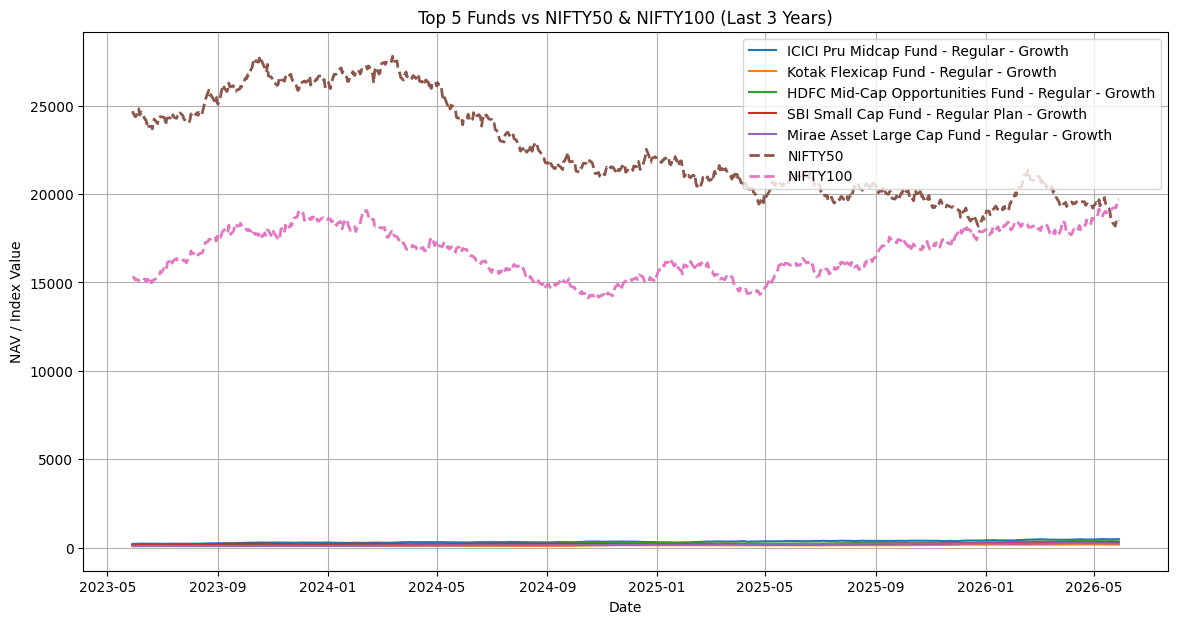

In [ ]:
# Plot Top 5 Funds vs NIFTY50 & NIFTY100 (Normalized Performance)

plt.figure(figsize=(14, 7))

# Plot Top 5 Funds
for amfi_code in top5_funds["amfi_code"]:

    fund_data = nav_3yr[nav_3yr["amfi_code"] == amfi_code].copy()

    scheme_name = performance_df.loc[
        performance_df["amfi_code"] == amfi_code,
        "scheme_name"
    ].values[0]

    # Normalize NAV
    fund_data["Normalized_NAV"] = (
        fund_data["nav"] /
        fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        fund_data["Normalized_NAV"],
        label=scheme_name
    )

# Prepare benchmark data
benchmark_3yr = benchmark_df[
    benchmark_df["date"] >= start_date
].copy()

# NIFTY50
nifty50 = benchmark_3yr[
    benchmark_3yr["index_name"] == "NIFTY50"
].copy()

nifty50["Normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50["Normalized"],
    linestyle="--",
    linewidth=2,
    label="NIFTY50"
)

# NIFTY100
nifty100 = benchmark_3yr[
    benchmark_3yr["index_name"] == "NIFTY100"
].copy()

nifty100["Normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100["Normalized"],
    linestyle="--",
    linewidth=2,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3-Year Normalized Performance)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend(fontsize=8)
plt.grid(True)

# Save Chart
plt.savefig(
    "../charts/performance/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
# Compute Tracking Error for Top 5 Funds

tracking_error_list = []

for amfi_code in top5_funds["amfi_code"]:

    fund_returns = nav_df[
        nav_df["amfi_code"] == amfi_code
    ][["date", "daily_return"]]

    merged = fund_returns.merge(
        nifty100_df[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    scheme_name = performance_df.loc[
        performance_df["amfi_code"] == amfi_code,
        "scheme_name"
    ].values[0]

    tracking_error_list.append({
        "amfi_code": amfi_code,
        "scheme_name": scheme_name,
        "Tracking_Error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_error_list)

display(tracking_error_df)

,amfi_code,scheme_name,Tracking_Error
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231968
1,120843,Kotak Flexicap Fund - Regular - Growth,0.206425
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
3,119598,SBI Small Cap Fund - Regular Plan - Growth,0.283881
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.189664


## 11. Exporting Results

In [88]:
# Export required CSV files

scorecard_df.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

print("CSV files exported successfully.")

CSV files exported successfully.


In [89]:
import os

print("Generated Files:")
print("-" * 30)

for file in os.listdir("../outputs"):
    print(file)

Generated Files:
------------------------------
alpha_beta.csv
fund_scorecard.csv
